# Stroke Prediction - Model Comparison

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

### EDA

In [7]:
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [8]:
print(df.tail())

         id  gender   age  hypertension  heart_disease ever_married  \
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
5105        Private          Urban              83.75   NaN     never smoked   
5106  Self-employed          Urban             125.20  40.0     never smoked   
5107  Self-employed          Rural              82.99  30.6     never smoked   
5108        Private          Rural             166.29  25.6  formerly smoked   
5109       Govt_job          Urban              85.28  26.2          Unknown   

      stroke  
5105       0  
5106       0  
5107       0  
5108       0  
5109       0  


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [10]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [11]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Preprocessing

In [12]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [13]:
# --- Balance the dataset ---
# 1. Separate the stroke and no-stroke cases
stroke_df = df[df['stroke'] == 1]
no_stroke_df = df[df['stroke'] == 0]

# 2. "Cut" the no-stroke cases to match the number of stroke cases
# Since you have 249 stroke cases, we will take exactly 249 no-stroke cases
no_stroke_cut = no_stroke_df.sample(n=len(stroke_df), random_state=42)

# 3. Combine them back into a new balanced dataframe
df_balanced = pd.concat([stroke_df, no_stroke_cut])

# 4. Shuffle the data so the model doesn't see all 0s then all 1s
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Check the new counts (Should be 249 each)
print("New Class Distribution:")
print(df['stroke'].value_counts())

New Class Distribution:
stroke
0    249
1    249
Name: count, dtype: int64


In [14]:
df.select_dtypes(include='object').columns

C:\Users\HP\AppData\Local\Temp\ipykernel_19632\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### Targets and labels

In [16]:
x = df.drop('stroke', axis=1)
y = df['stroke']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.72

### Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
dt.fit(X_train, y_train)

# ----------------------------
# Make predictions
y_pred = dt.predict(X_test)

# ----------------------------
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Matplotlib is building the font cache; this may take a moment.


Decision Tree Accuracy: 69.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.68      0.69        50
           1       0.69      0.70      0.69        50

    accuracy                           0.69       100
   macro avg       0.69      0.69      0.69       100
weighted avg       0.69      0.69      0.69       100

Confusion Matrix:
 [[34 16]
 [15 35]]


### Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

# ----------------------------
# Predict on test set
y_pred = rf.predict(X_test)

# ----------------------------
# Evaluate
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 71.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.71        50
           1       0.71      0.70      0.71        50

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100


Confusion Matrix:
 [[36 14]
 [15 35]]


### KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----------------------------
# Create KNN classifier
knn = KNeighborsClassifier(
    n_neighbors=5,       # you can change k
    metric='minkowski',  # distance metric (Euclidean by default)
    p=2
)

# ----------------------------
# Train KNN
knn.fit(X_train, y_train)

# ----------------------------
# Predict on test set
y_pred = knn.predict(X_test)

# ----------------------------
# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ----------------------------
# Find best k (hyperparameter tuning)
best_k = 1
best_acc = 0
for k in range(1, 21):
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    y_pred_test = knn_test.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    if acc > best_acc:
        best_acc = acc
        best_k = k

print(f"Best k: {best_k} with Accuracy: {best_acc*100:.2f}%")

KNN Accuracy: 57.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.62      0.59        50
           1       0.58      0.52      0.55        50

    accuracy                           0.57       100
   macro avg       0.57      0.57      0.57       100
weighted avg       0.57      0.57      0.57       100

Confusion Matrix:
 [[31 19]
 [24 26]]
Best k: 19 with Accuracy: 60.00%


Final KNN Accuracy with k=19: 60.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.62      0.61        50
           1       0.60      0.58      0.59        50

    accuracy                           0.60       100
   macro avg       0.60      0.60      0.60       100
weighted avg       0.60      0.60      0.60       100

Confusion Matrix:
 [[31 19]
 [21 29]]


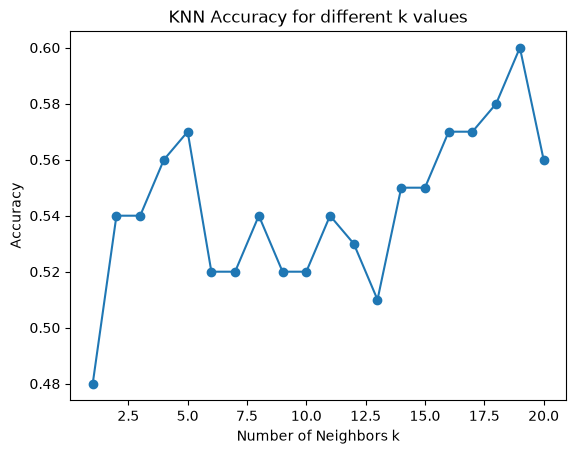

In [23]:
# Retrain using the best k
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predict again
y_pred_final = knn_final.predict(X_test)

# Evaluate
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"Final KNN Accuracy with k={best_k}: {accuracy_final*100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

import matplotlib.pyplot as plt

acc_list = []
k_range = range(1, 21)
for k in k_range:
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train, y_train)
    y_pred_test = knn_test.predict(X_test)
    acc_list.append(accuracy_score(y_test, y_pred_test))

plt.plot(k_range, acc_list, marker='o')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for different k values')
plt.show()

### Model comparison

                 Model  Accuracy  Recall (Catching Strokes)  F1-Score
0  Logistic Regression      0.72                       0.72  0.720000
1        Decision Tree      0.69                       0.70  0.693069
2        Random Forest      0.71                       0.70  0.707071
3                  KNN      0.60                       0.58  0.591837


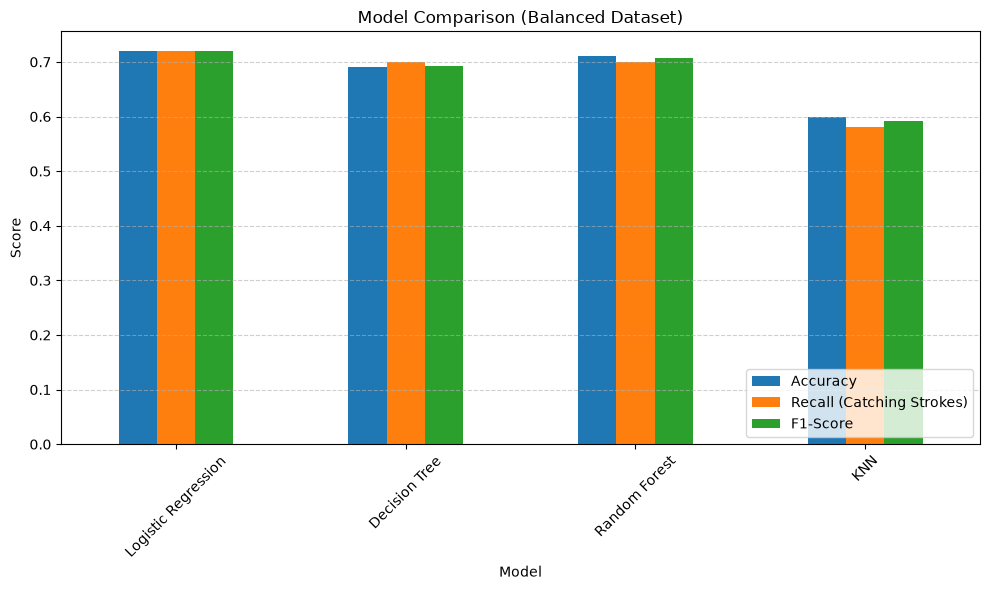

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming your models are named: log_reg, dt, rf, knn_final
models_dict = {
    'Logistic Regression': (log_reg, X_test_scaled),
    'Decision Tree': (dt, X_test),
    'Random Forest': (rf, X_test),
    'KNN': (knn_final, X_test)
}

comparison_data = []

for name, (model, data) in models_dict.items():
    preds = model.predict(data)
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Recall (Catching Strokes)': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds)
    })

# Create table and Plot
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Plotting for slides
comparison_df.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title("Model Comparison (Balanced Dataset)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()